**Task 0**

Find one dataset from EUROSTATS of your choice and create at least 3 different visualizations from the data. Show some trends, structure of the data, some interesting insights.

Steps:
- pick up the dataset
- explore the data to better understand them
- pick up a subset of the data (`indic_de` is something you should care about, it contains indicators, and `geo` to filter the countries or whole EU).
- pick up a proper kind of a plot and display the results.

rows, cols: (14519, 26)
geo column: geo\TIME_PERIOD
indicator column used: hhwkstat
years range: 2006 - 2025
sample indicator values: <StringArray>
[      'GE1_WRK_A1_NWRK',     'GE1_WRK_PT_OTH_FT',                   'NRP',
                  'NWRK',           'NWRK_X_EDUC', 'NWRK_X_EDUC_INAC_GE65',
                 'TOTAL',                   'WRK']
Length: 8, dtype: str


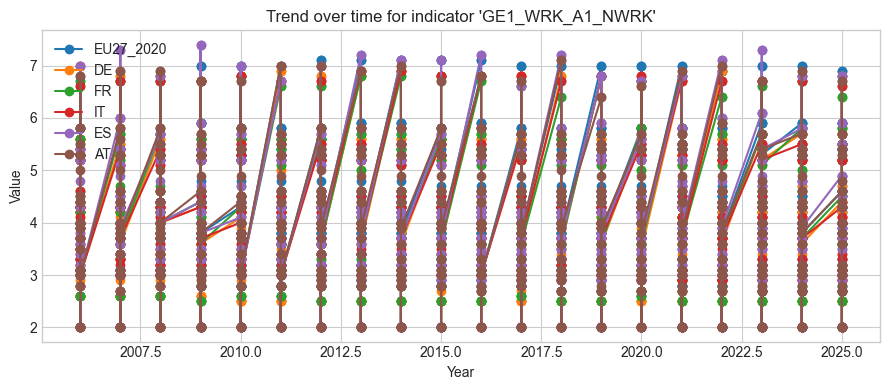

/var/folders/z7/wb0j9hrs349bb90z5qr6vv440000gn/T/ipykernel_10848/2527384558.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


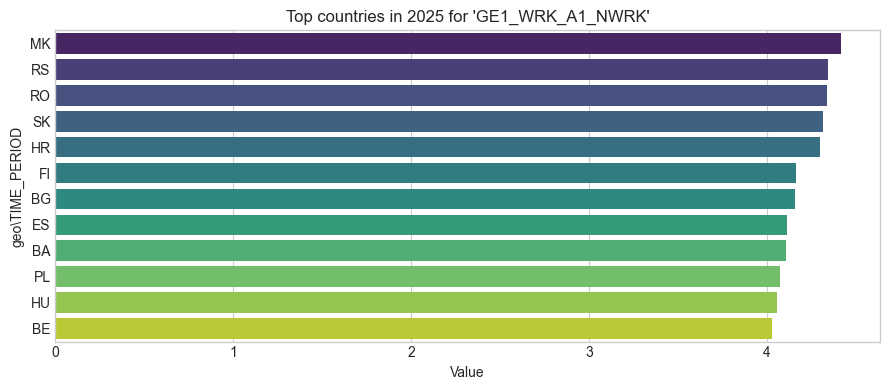

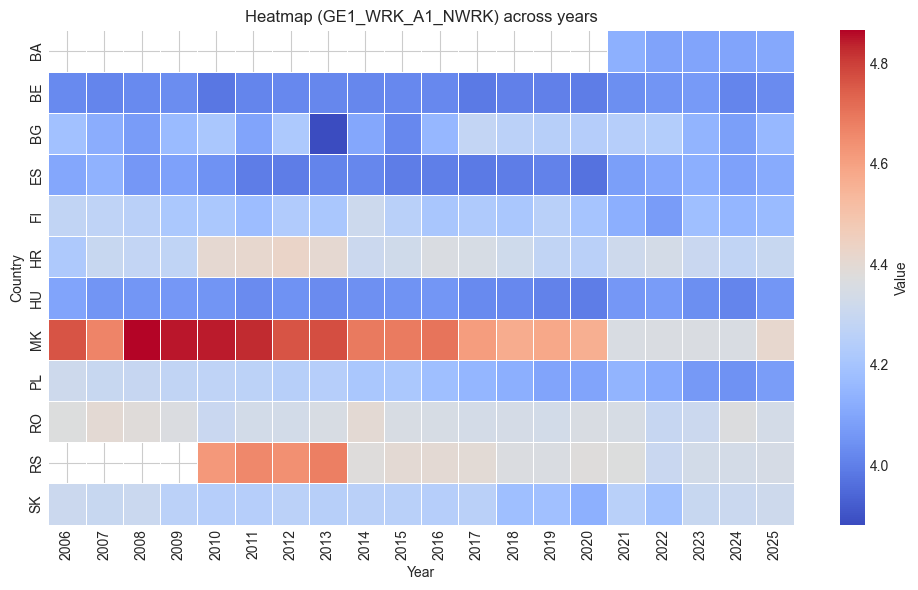

In [9]:
import seaborn as sns

# Exploration + 3 visualizations for the loaded EUROSTAT dataset (using `tmp` DataFrame)

# copy dataset to a working variable
dataset_df = tmp.copy()

# detect key column names
year_cols = [c for c in dataset_df.columns if isinstance(c, str) and c.isdigit()]
geo_col = next((c for c in dataset_df.columns if c.lower().startswith('geo')), None)
# prefer 'indic_de' if present, otherwise fallback to likely indicator columns
indicator_col = next((c for c in ['indic_de', 'indicator', 'indic'] if c in dataset_df.columns), 
                     next((c for c in ['hhwkstat', 'phhcomp', 'n_child', 'freq'] if c in dataset_df.columns), None))

# quick summary
print("rows, cols:", dataset_df.shape)
print("geo column:", geo_col)
print("indicator column used:", indicator_col)
print("years range:", min(year_cols), "-", max(year_cols))
print("sample indicator values:", dataset_df[indicator_col].dropna().unique()[:8])

# reshape to long
long = dataset_df.melt(id_vars=[c for c in dataset_df.columns if c not in year_cols],
                       value_vars=year_cols, var_name='year', value_name='value')
long['year'] = long['year'].astype(int)

# choose one indicator value to focus on (first non-null)
focus_value = long[indicator_col].dropna().unique()[0]
subset = long[long[indicator_col] == focus_value].copy()

# pick countries to compare: prefer EU and major members if present
candidates = ['EU27_2020', 'EU', 'DE', 'FR', 'IT', 'ES', 'AT']
available = [g for g in candidates if g in subset[geo_col].unique()]
if not available:
    # fallback to top 5 most frequent geos
    available = list(subset[geo_col].value_counts().head(5).index)

# plotting (imports safe for a standalone cell)
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# 1) Line plot: trend over time for selected countries
plt.figure(figsize=(9,4))
for g in available:
    s = subset[subset[geo_col]==g].sort_values('year')
    plt.plot(s['year'], s['value'], marker='o', label=g)
plt.title(f"Trend over time for indicator '{focus_value}'")
plt.xlabel('Year'); plt.ylabel('Value'); plt.legend()
plt.tight_layout()
plt.show()

# 2) Bar chart: latest year comparison (top countries)
latest_year = subset['year'].max()
latest = subset[subset['year']==latest_year].dropna(subset=['value'])
top_countries = latest.groupby(geo_col)['value'].mean().sort_values(ascending=False).head(12)
plt.figure(figsize=(9,4))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title(f"Top countries in {latest_year} for '{focus_value}'")
plt.xlabel('Value'); plt.tight_layout(); plt.show()

# 3) Heatmap: countries x years for the focus indicator (limited to top 12 by data volume)
heat_countries = latest.index[:12] if len(latest.index)>=1 else available
pivot = subset[subset[geo_col].isin(top_countries.index)].pivot_table(index=geo_col, columns='year', values='value')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=False, cmap='coolwarm', cbar_kws={'label':'Value'}, linewidths=.5)
plt.title(f"Heatmap ({focus_value}) across years")
plt.xlabel('Year'); plt.ylabel('Country'); plt.tight_layout(); plt.show()